In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx


In [3]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df.columns = df.columns.str.strip()

print(" Dataset Shape:", df.shape)
df.head()


 Dataset Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [4]:
median_time = df["Delivery_Time"].median()
df["Delivery_Status"] = np.where(df["Delivery_Time"] <= median_time, "Fast", "Delayed")

df["Delivery_Status"].value_counts()


Delivery_Status
Fast       100
Delayed    100
Name: count, dtype: int64

In [5]:
def is_rush_hour(time_str):
    try:
        hour = int(str(time_str).split(":")[0])
        return "Rush" if (12 <= hour <= 14) or (18 <= hour <= 21) else "NonRush"
    except:
        return "NonRush"

df["Rush_Type"] = df["Order_Time"].apply(is_rush_hour)

df[["Order_Time", "Rush_Type"]].head()


,Order_Time,Rush_Type
0,Afternoon,NonRush
1,Night,NonRush
2,Night,NonRush
3,Evening,NonRush
4,Night,NonRush


In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def extract_lat_lon(location):
    if pd.isna(location):
        return (np.nan, np.nan)
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(location))
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return (np.nan, np.nan)

df["Customer_Lat"], df["Customer_Lon"] = zip(*df["Customer_Location"].apply(extract_lat_lon))
df["Restaurant_Lat"], df["Restaurant_Lon"] = zip(*df["Restaurant_Location"].apply(extract_lat_lon))

df["Distance_km"] = df.apply(
    lambda row: haversine(row["Restaurant_Lat"], row["Restaurant_Lon"],
                          row["Customer_Lat"], row["Customer_Lon"])
    if pd.notnull(row["Customer_Lat"]) and pd.notnull(row["Customer_Lon"]) and
       pd.notnull(row["Restaurant_Lat"]) and pd.notnull(row["Restaurant_Lon"])
    else np.nan,
    axis=1
)

df[["Distance", "Distance_km"]].head()


,Distance,Distance_km
0,1.57,775.651198
1,21.32,1042.385597
2,6.95,476.220706
3,13.79,389.912629
4,6.72,806.505886


In [7]:
def make_bins(series, name):
    return pd.qcut(series, q=3, labels=[f"{name}_Low", f"{name}_Medium", f"{name}_High"])

df["Distance_Level"] = make_bins(df["Distance_km"].fillna(df["Distance_km"].median()), "Distance")
df["Cost_Level"] = make_bins(df["Order_Cost"], "Cost")
df["Tip_Level"] = make_bins(df["Tip_Amount"], "Tip")

df[["Distance_Level", "Cost_Level", "Tip_Level"]].head()


,Distance_Level,Cost_Level,Tip_Level
0,Distance_High,Cost_High,Tip_High
1,Distance_High,Cost_Low,Tip_Low
2,Distance_Medium,Cost_High,Tip_High
3,Distance_Low,Cost_Low,Tip_High
4,Distance_High,Cost_Low,Tip_Low


In [8]:
transactions = df[[
    "Weather_Conditions",
    "Traffic_Conditions",
    "Order_Priority",
    "Vehicle_Type",
    "Rush_Type",
    "Distance_Level",
    "Cost_Level",
    "Tip_Level",
    "Delivery_Status"
]].astype(str)

basket = pd.get_dummies(transactions)

print(" Basket Shape:", basket.shape)
basket.head()


 Basket Shape: (200, 25)


,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,...,Distance_Level_Distance_Low,Distance_Level_Distance_Medium,Cost_Level_Cost_High,Cost_Level_Cost_Low,Cost_Level_Cost_Medium,Tip_Level_Tip_High,Tip_Level_Tip_Low,Tip_Level_Tip_Medium,Delivery_Status_Delayed,Delivery_Status_Fast
0,False,True,False,False,False,False,True,False,False,True,...,False,False,True,False,False,True,False,False,False,True
1,True,False,False,False,False,False,True,False,True,False,...,False,False,False,True,False,False,True,False,False,True
2,False,False,True,False,False,False,True,True,False,False,...,False,True,True,False,False,True,False,False,False,True
3,True,False,False,False,False,True,False,False,False,True,...,True,False,False,True,False,True,False,False,True,False
4,False,True,False,False,True,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,True


In [9]:
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

print(" Frequent Itemsets Found:", frequent_itemsets.shape[0])
frequent_itemsets.sort_values("support", ascending=False).head(10)


 Frequent Itemsets Found: 1311


,support,itemsets
13,1.000,(Rush_Type_NonRush)
23,0.500,(Delivery_Status_Delayed)
24,0.500,(Delivery_Status_Fast)
250,0.500,"(Rush_Type_NonRush, Delivery_Status_Delayed)"
251,0.500,"(Delivery_Status_Fast, Rush_Type_NonRush)"
130,0.405,"(Rush_Type_NonRush, Traffic_Conditions_Low)"
5,0.405,(Traffic_Conditions_Low)
8,0.375,(Order_Priority_Low)
178,0.375,"(Order_Priority_Low, Rush_Type_NonRush)"
217,0.345,"(Vehicle_Type_Bike, Rush_Type_NonRush)"


In [10]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print(" Total Rules:", rules.shape[0])
rules.sort_values("lift", ascending=False).head(10)


 Total Rules: 919


d:\ML course\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
486,"(Rush_Type_NonRush, Cost_Level_Cost_Medium, Tr...",(Distance_Level_Distance_Medium),0.070,0.330,0.060,0.857143,2.597403,1.0,0.036900,4.6900,0.661290,0.176471,0.786780,0.519481
147,"(Cost_Level_Cost_Medium, Traffic_Conditions_High)",(Distance_Level_Distance_Medium),0.070,0.330,0.060,0.857143,2.597403,1.0,0.036900,4.6900,0.661290,0.176471,0.786780,0.519481
489,"(Cost_Level_Cost_Medium, Traffic_Conditions_High)","(Rush_Type_NonRush, Distance_Level_Distance_Me...",0.070,0.330,0.060,0.857143,2.597403,1.0,0.036900,4.6900,0.661290,0.176471,0.786780,0.519481
594,"(Cost_Level_Cost_Medium, Delivery_Status_Delay...",(Traffic_Conditions_Low),0.065,0.405,0.055,0.846154,2.089269,1.0,0.028675,3.8675,0.557608,0.132530,0.741435,0.490978
916,"(Rush_Type_NonRush, Cost_Level_Cost_Medium, De...",(Traffic_Conditions_Low),0.065,0.405,0.055,0.846154,2.089269,1.0,0.028675,3.8675,0.557608,0.132530,0.741435,0.490978
918,"(Cost_Level_Cost_Medium, Delivery_Status_Delay...","(Rush_Type_NonRush, Traffic_Conditions_Low)",0.065,0.405,0.055,0.846154,2.089269,1.0,0.028675,3.8675,0.557608,0.132530,0.741435,0.490978
148,"(Distance_Level_Distance_Medium, Traffic_Condi...",(Cost_Level_Cost_Medium),0.090,0.330,0.060,0.666667,2.020202,1.0,0.030300,2.0100,0.554945,0.166667,0.502488,0.424242
490,"(Distance_Level_Distance_Medium, Traffic_Condi...","(Rush_Type_NonRush, Cost_Level_Cost_Medium)",0.090,0.330,0.060,0.666667,2.020202,1.0,0.030300,2.0100,0.554945,0.166667,0.502488,0.424242
488,"(Rush_Type_NonRush, Distance_Level_Distance_Me...",(Cost_Level_Cost_Medium),0.090,0.330,0.060,0.666667,2.020202,1.0,0.030300,2.0100,0.554945,0.166667,0.502488,0.424242
657,"(Order_Priority_High, Rush_Type_NonRush, Cost_...",(Vehicle_Type_Bicycle),0.080,0.345,0.055,0.687500,1.992754,1.0,0.027400,2.0960,0.541502,0.148649,0.522901,0.423460


In [11]:
strong_rules = rules[
    (rules["lift"] >= 1.2) &
    (rules["confidence"] >= 0.6)
].copy()

print(" Strong Rules:", strong_rules.shape[0])
strong_rules.sort_values("lift", ascending=False).head(10)


 Strong Rules: 264


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
147,"(Cost_Level_Cost_Medium, Traffic_Conditions_High)",(Distance_Level_Distance_Medium),0.070,0.330,0.060,0.857143,2.597403,1.0,0.036900,4.6900,0.661290,0.176471,0.786780,0.519481
486,"(Rush_Type_NonRush, Cost_Level_Cost_Medium, Tr...",(Distance_Level_Distance_Medium),0.070,0.330,0.060,0.857143,2.597403,1.0,0.036900,4.6900,0.661290,0.176471,0.786780,0.519481
489,"(Cost_Level_Cost_Medium, Traffic_Conditions_High)","(Rush_Type_NonRush, Distance_Level_Distance_Me...",0.070,0.330,0.060,0.857143,2.597403,1.0,0.036900,4.6900,0.661290,0.176471,0.786780,0.519481
594,"(Cost_Level_Cost_Medium, Delivery_Status_Delay...",(Traffic_Conditions_Low),0.065,0.405,0.055,0.846154,2.089269,1.0,0.028675,3.8675,0.557608,0.132530,0.741435,0.490978
916,"(Rush_Type_NonRush, Cost_Level_Cost_Medium, De...",(Traffic_Conditions_Low),0.065,0.405,0.055,0.846154,2.089269,1.0,0.028675,3.8675,0.557608,0.132530,0.741435,0.490978
918,"(Cost_Level_Cost_Medium, Delivery_Status_Delay...","(Rush_Type_NonRush, Traffic_Conditions_Low)",0.065,0.405,0.055,0.846154,2.089269,1.0,0.028675,3.8675,0.557608,0.132530,0.741435,0.490978
488,"(Rush_Type_NonRush, Distance_Level_Distance_Me...",(Cost_Level_Cost_Medium),0.090,0.330,0.060,0.666667,2.020202,1.0,0.030300,2.0100,0.554945,0.166667,0.502488,0.424242
490,"(Distance_Level_Distance_Medium, Traffic_Condi...","(Rush_Type_NonRush, Cost_Level_Cost_Medium)",0.090,0.330,0.060,0.666667,2.020202,1.0,0.030300,2.0100,0.554945,0.166667,0.502488,0.424242
148,"(Distance_Level_Distance_Medium, Traffic_Condi...",(Cost_Level_Cost_Medium),0.090,0.330,0.060,0.666667,2.020202,1.0,0.030300,2.0100,0.554945,0.166667,0.502488,0.424242
657,"(Order_Priority_High, Rush_Type_NonRush, Cost_...",(Vehicle_Type_Bicycle),0.080,0.345,0.055,0.687500,1.992754,1.0,0.027400,2.0960,0.541502,0.148649,0.522901,0.423460


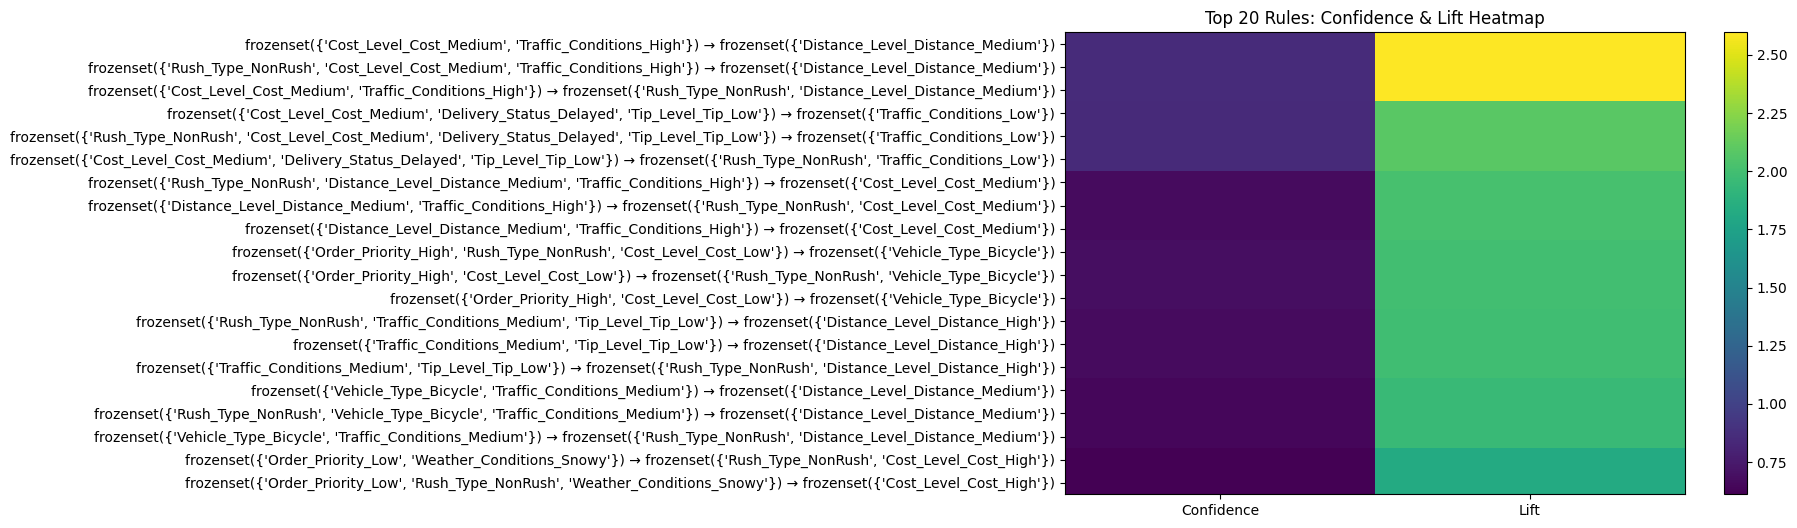

In [12]:
top_heat = strong_rules.sort_values("lift", ascending=False).head(20).copy()
top_heat["rule"] = top_heat["antecedents"].astype(str) + " → " + top_heat["consequents"].astype(str)

plt.figure(figsize=(10,6))
plt.imshow(top_heat[["confidence", "lift"]].values, aspect="auto")
plt.yticks(range(len(top_heat)), top_heat["rule"])
plt.xticks([0, 1], ["Confidence", "Lift"])
plt.title("Top 20 Rules: Confidence & Lift Heatmap")
plt.colorbar()
plt.show()


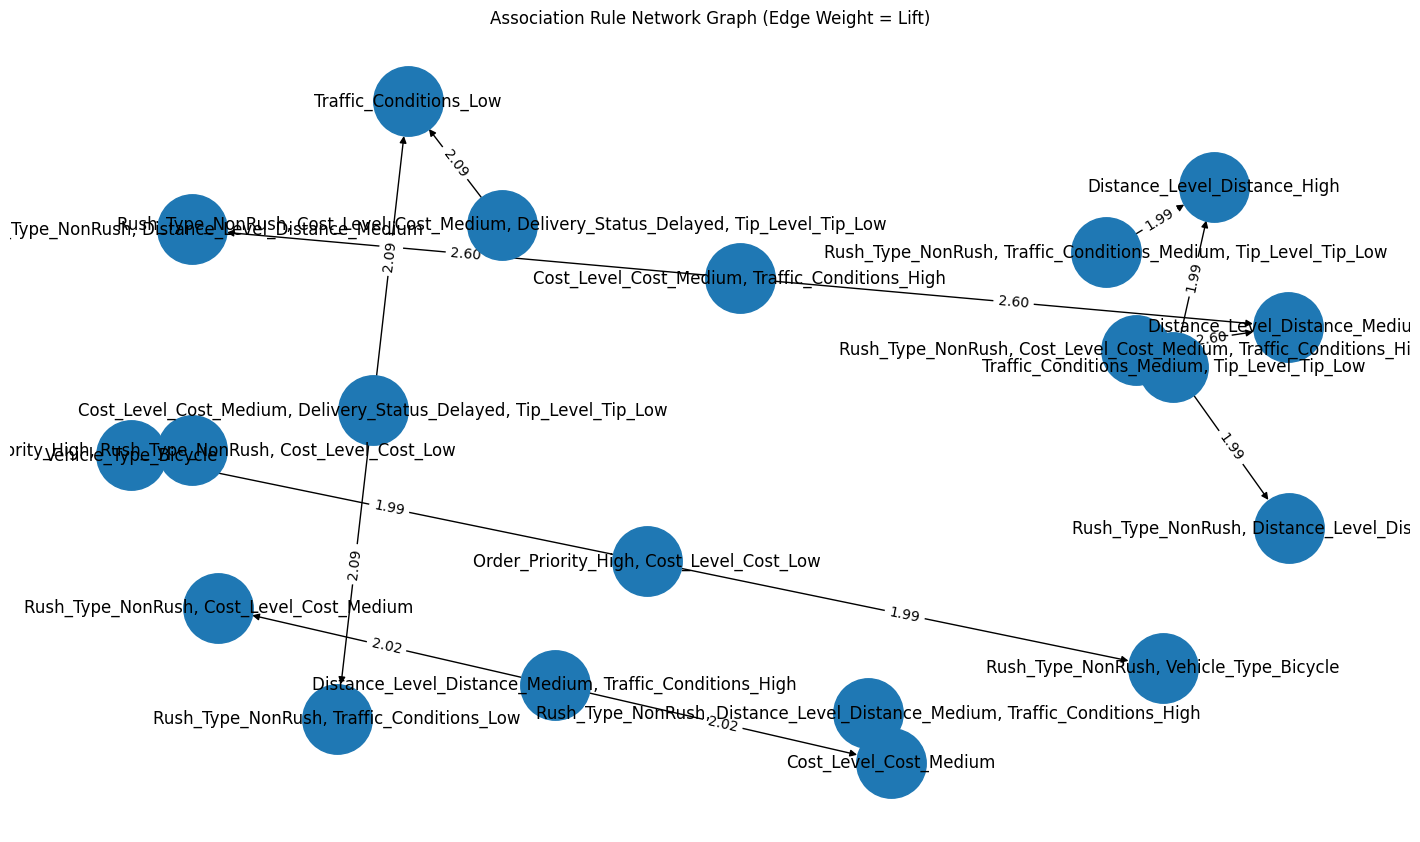

In [13]:
top_net = strong_rules.sort_values("lift", ascending=False).head(15)

G = nx.DiGraph()

for _, row in top_net.iterrows():
    antecedent = ", ".join(list(row["antecedents"]))
    consequent = ", ".join(list(row["consequents"]))
    lift = row["lift"]
    
    G.add_node(antecedent)
    G.add_node(consequent)
    G.add_edge(antecedent, consequent, weight=lift)

plt.figure(figsize=(14,8))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_size=2500)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rule Network Graph (Edge Weight = Lift)")
plt.show()


In [14]:
thresholds = [
    {"min_support": 0.03, "min_confidence": 0.5},
    {"min_support": 0.05, "min_confidence": 0.6},
    {"min_support": 0.07, "min_confidence": 0.7}
]

robustness_results = []

for t in thresholds:
    itemsets = apriori(basket, min_support=t["min_support"], use_colnames=True)
    r = association_rules(itemsets, metric="confidence", min_threshold=t["min_confidence"])
    strong_r = r[(r["lift"] >= 1.2)]
    
    robustness_results.append({
        "Min_Support": t["min_support"],
        "Min_Confidence": t["min_confidence"],
        "Frequent_Itemsets": itemsets.shape[0],
        "Rules_Generated": r.shape[0],
        "Strong_Rules_(Lift>=1.2)": strong_r.shape[0]
    })

pd.DataFrame(robustness_results)


d:\ML course\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
d:\ML course\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
d:\ML course\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,Min_Support,Min_Confidence,Frequent_Itemsets,Rules_Generated,Strong_Rules_(Lift>=1.2)
0,0.03,0.5,3309,6006,3717
1,0.05,0.6,1311,919,264
2,0.07,0.7,641,332,12


In [15]:
def get_top_rule_set(min_support, min_confidence, topn=10):
    itemsets = apriori(basket, min_support=min_support, use_colnames=True)
    r = association_rules(itemsets, metric="confidence", min_threshold=min_confidence)
    r = r[(r["lift"] >= 1.2)].sort_values("lift", ascending=False).head(topn)
    return set((str(a), str(c)) for a, c in zip(r["antecedents"], r["consequents"]))

rule_sets = []
for t in thresholds:
    rule_sets.append(get_top_rule_set(t["min_support"], t["min_confidence"], topn=10))

common_rules = set.intersection(*rule_sets) if len(rule_sets) > 1 else rule_sets[0]
print(" Common Top Rules across threshold tests:", len(common_rules))

list(common_rules)[:10]


 Common Top Rules across threshold tests: 0


d:\ML course\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
d:\ML course\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
d:\ML course\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


[]

In [16]:
X = df.drop(columns=["Delivery_Time", "Delivery_Status", "Order_ID"])
y = (df["Delivery_Status"] == "Delayed").astype(int)

categorical_cols = ["Weather_Conditions", "Traffic_Conditions", "Order_Priority", "Vehicle_Type", "Rush_Type"]
numerical_cols = [
    "Distance", "Distance_km",
    "Delivery_Person_Experience",
    "Restaurant_Rating", "Customer_Rating",
    "Order_Cost", "Tip_Amount"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_scores = cross_val_score(lr_pipe, X, y, cv=cv, scoring="accuracy")

print("Logistic Regression CV Accuracy:", lr_scores.mean(), "+/-", lr_scores.std())


Logistic Regression CV Accuracy: 0.505 +/- 0.043011626335213125


In [18]:
lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print(" Logistic Regression Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


 Logistic Regression Test Accuracy: 0.45
              precision    recall  f1-score   support

           0       0.45      0.50      0.48        20
           1       0.44      0.40      0.42        20

    accuracy                           0.45        40
   macro avg       0.45      0.45      0.45        40
weighted avg       0.45      0.45      0.45        40



In [19]:
X_processed = preprocessor.fit_transform(X)
X_dense = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed
n_features = X_dense.shape[1]

img_size = max(4, int(np.ceil(np.sqrt(n_features))))
target_size = img_size * img_size
pad_width = target_size - n_features

X_padded = np.pad(X_dense, ((0,0), (0,pad_width)), mode="constant")
X_images = X_padded.reshape(-1, img_size, img_size, 1)

print(" CNN Input Shape:", X_images.shape)


 CNN Input Shape: (200, 5, 5, 1)


In [21]:
def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (2,2), activation="relu", padding="same"),
        MaxPooling2D((2,2)),
        Conv2D(64, (2,2), activation="relu", padding="same"),
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

cnn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cnn_scores = []

for fold, (tr, te) in enumerate(cnn_cv.split(X_images, y), start=1):
    X_tr, X_te = X_images[tr], X_images[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    cnn = build_cnn(X_tr.shape[1:])
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

    cnn.fit(X_tr, y_tr, validation_split=0.2, epochs=10, batch_size=16,
            callbacks=[early_stop], verbose=0)

    loss, acc = cnn.evaluate(X_te, y_te, verbose=0)
    cnn_scores.append(acc)
    print(f"Fold {fold} CNN Accuracy: {acc:.4f}")

print("\n CNN CV Mean Accuracy:", np.mean(cnn_scores))
print(" CNN CV Std Accuracy :", np.std(cnn_scores))


d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __arr

Fold 1 CNN Accuracy: 0.5000


d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __arr

Fold 2 CNN Accuracy: 0.5500


d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __arr

...

d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __arr

Fold 4 CNN Accuracy: 0.5000


d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __arr

Fold 5 CNN Accuracy: 0.5000

 CNN CV Mean Accuracy: 0.5050000011920929
 CNN CV Std Accuracy : 0.024494903267870422


d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
d:\ML course\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


In [22]:
delayed_rules = strong_rules[
    strong_rules["consequents"].astype(str).str.contains("Delivery_Status_Delayed")
].sort_values("lift", ascending=False)

delayed_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)


,antecedents,consequents,support,confidence,lift
912,"(Vehicle_Type_Bicycle, Cost_Level_Cost_Medium,...","(Rush_Type_NonRush, Delivery_Status_Delayed)",0.055,0.785714,1.571429
545,"(Vehicle_Type_Bicycle, Cost_Level_Cost_Medium,...",(Delivery_Status_Delayed),0.055,0.785714,1.571429
910,"(Rush_Type_NonRush, Vehicle_Type_Bicycle, Cost...",(Delivery_Status_Delayed),0.055,0.785714,1.571429
372,"(Weather_Conditions_Rainy, Rush_Type_NonRush, ...",(Delivery_Status_Delayed),0.050,0.769231,1.538462
49,"(Weather_Conditions_Rainy, Traffic_Conditions_...",(Delivery_Status_Delayed),0.050,0.769231,1.538462
374,"(Weather_Conditions_Rainy, Traffic_Conditions_...","(Rush_Type_NonRush, Delivery_Status_Delayed)",0.050,0.769231,1.538462
524,"(Traffic_Conditions_Low, Order_Priority_Low, T...",(Delivery_Status_Delayed),0.050,0.769231,1.538462
900,"(Order_Priority_Low, Tip_Level_Tip_Low, Traffi...","(Rush_Type_NonRush, Delivery_Status_Delayed)",0.050,0.769231,1.538462
898,"(Order_Priority_Low, Rush_Type_NonRush, Tip_Le...",(Delivery_Status_Delayed),0.050,0.769231,1.538462
443,"(Weather_Conditions_Sunny, Rush_Type_NonRush, ...",(Delivery_Status_Delayed),0.070,0.736842,1.473684


In [23]:
top_n = 8
top_delay = delayed_rules.head(top_n)

print(f"Top {top_n} Rules Associated with DELAYED Deliveries:\n")

for _, row in top_delay.iterrows():
    ant = ", ".join(list(row["antecedents"]))
    con = ", ".join(list(row["consequents"]))
    print(f"If [{ant}] → then [{con}]")
    print(f"Support={row['support']:.3f}, Confidence={row['confidence']:.3f}, Lift={row['lift']:.3f}")
    print("-" * 70)


Top 8 Rules Associated with DELAYED Deliveries:

If [Vehicle_Type_Bicycle, Cost_Level_Cost_Medium, Traffic_Conditions_Low] → then [Rush_Type_NonRush, Delivery_Status_Delayed]
Support=0.055, Confidence=0.786, Lift=1.571
----------------------------------------------------------------------
If [Vehicle_Type_Bicycle, Cost_Level_Cost_Medium, Traffic_Conditions_Low] → then [Delivery_Status_Delayed]
Support=0.055, Confidence=0.786, Lift=1.571
----------------------------------------------------------------------
If [Rush_Type_NonRush, Vehicle_Type_Bicycle, Cost_Level_Cost_Medium, Traffic_Conditions_Low] → then [Delivery_Status_Delayed]
Support=0.055, Confidence=0.786, Lift=1.571
----------------------------------------------------------------------
If [Weather_Conditions_Rainy, Rush_Type_NonRush, Traffic_Conditions_Medium] → then [Delivery_Status_Delayed]
Support=0.050, Confidence=0.769, Lift=1.538
----------------------------------------------------------------------
If [Weather_Conditions_

Final Summary 


In this assignment, I analyzed the Food Delivery Time Prediction dataset using association rule mining and supervised learning models to understand the key factors influencing delayed deliveries. I engineered meaningful features such as Rush vs Non-Rush hour and distance categories, converted delivery conditions into transaction-style one-hot data, and applied the Apriori algorithm to extract frequent itemsets and association rules. Rule quality was evaluated using support, confidence, and lift, and interpretation was improved using advanced visualizations including a heatmap and a network graph to clearly show rule relationships. To validate rule robustness, I performed a threshold sensitivity analysis by comparing the number of frequent itemsets and strong rules generated under different minimum support and confidence values, and I also checked rule stability by identifying rules that remained consistent across thresholds. To connect Phase 2 results with Phase 3 evaluation, I trained and validated predictive models including Logistic Regression and a CNN-based model (feature-to-image transformation), comparing their performance using cross-validation accuracy. Finally, strong rules linked to delayed deliveries were summarized into actionable recommendations, such as prioritizing rider allocation during peak traffic conditions, applying rush-hour staffing strategies, and improving delivery routing for high-distance orders under unfavorable weather conditions